# Feature Space Optimization & Dimensionality Reduction

## Project Context
To address the evaluation criteria effectively, this notebook prepares the data using a **dual-pathway approach** for the modeling phase:
1. **Pathway A (Feature Selection):** Prioritizes business interpretability and actionable recommendations. We remove highly correlated/redundant features to prevent multicollinearity while keeping the original variables intact.
2. **Pathway B (PCA - Feature Extraction):** Prioritizes mathematical performance and dimensionality reduction. This will be used in the "Model Comparison" phase to contrast against Pathway A.

In [4]:
#Import fundamental libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import Machine Learning preprocessing tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#1. Load the clean dataset
file_path = "clean_WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (7043, 21)


**Base Feature Engineering**

Before branching into our two pathways, we must establish a common mathematical ground. Machine learning models and PCA require numerical inputs. 

**Steps performed:**
* **Isolate Target:** Separate `Churn` from the predictor features.
* **Drop Identifiers:** Remove `customerID` as it holds no predictive power.
* **One-Hot Encoding:** Convert categorical variables into binary dummy variables. We use `drop_first=True` to avoid the dummy variable trap.
* **Standardization:** Apply `StandardScaler` so all features have a mean of 0 and a standard deviation of 1.

In [5]:
#Separate target variable and drop identifier
target = df["Churn"]
X = df.drop(columns=["customerID", "Churn"])

#Apply One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

#Apply Standardization
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_encoded)

#Rebuild DataFrame for easier manipulation
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns)

print(f"Base Feature Engineering complete. Total encoded features: {X_scaled.shape[1]}")

Base Feature Engineering complete. Total encoded features: 30


**Pathway A: Feature Selection (Business Interpretability)**

For the primary business model, we need actionable insights. During the EDA, it is common to find that `TotalCharges` is highly collinear with `MonthlyCharges` and `tenure` (since Total ≈ Monthly * tenure). 

To improve model stability (especially for Logistic Regression) and maintain clear business interpretability, we drop the redundant `TotalCharges` feature.

In [6]:
#Create a copy for the Feature Selection pathway
X_features = X_scaled.copy()

#Drop 'TotalCharges' to prevent multicollinearity
if "TotalCharges" in X_features.columns:
    X_features = X_features.drop(columns=["TotalCharges"])

#Re-attach target and export for modeling
df_modeling_features = X_features.copy()
df_modeling_features["Churn"] = target.values

df_modeling_features.to_csv("dataset_for_modeling_features.csv", index=False)
print(f"Pathway A exported: 'dataset_for_modeling_features.csv' (Shape: {df_modeling_features.shape})")

Pathway A exported: 'dataset_for_modeling_features.csv' (Shape: (7043, 30))


**Pathway B: Principal Component Analysis (Model Comparison)**

For the secondary approach, we apply PCA to reduce the dimensionality of our feature space. This will allow us to evaluate if stripping the data of its original context in favor of orthogonal components improves the predictive performance of our algorithms.

We will use a **Scree Plot** to determine the optimal number of Principal Components needed to retain **90% of the cumulative explained variance**.

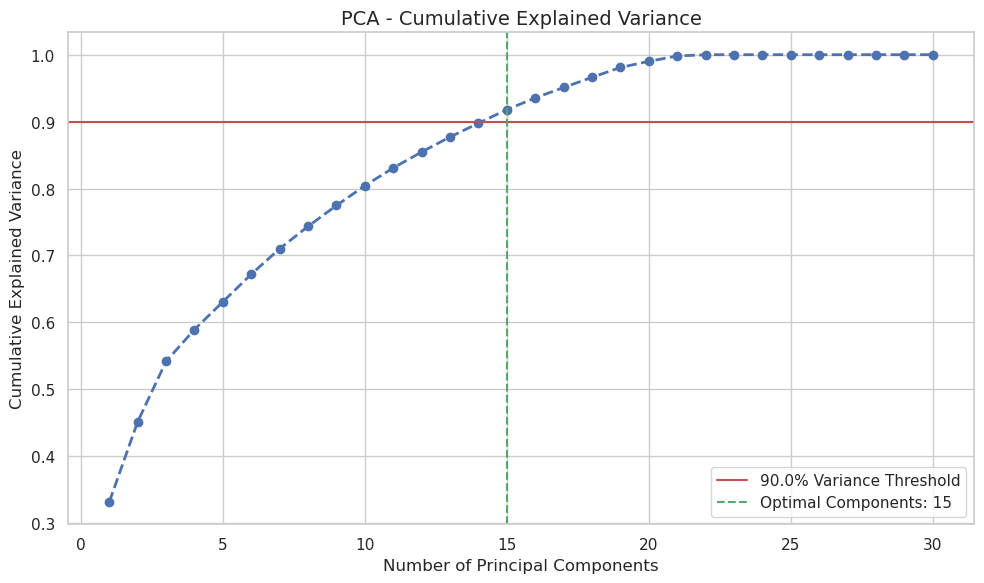

Optimal number of components to reach 90.0% variance: 15
Pathway B exported: 'dataset_for_modeling_pca.csv' (Shape: (7043, 16))


In [7]:
#Initialize and fit PCA on the scaled base dataset
pca = PCA()
pca.fit(X_scaled)

#Calculate variances
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

#Determine components for 90% variance threshold
target_variance = 0.90
optimal_components = np.argmax(cumulative_variance >= target_variance) + 1

#Plotting the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', linewidth=2)
plt.axhline(y=target_variance, color='r', linestyle='-', label=f'{target_variance*100}% Variance Threshold')
plt.axvline(x=optimal_components, color='g', linestyle='--', label=f'Optimal Components: {optimal_components}')

plt.title("PCA - Cumulative Explained Variance", fontsize=14)
plt.xlabel("Number of Principal Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Optimal number of components to reach {target_variance*100}% variance: {optimal_components}")

#Apply final PCA transformation
pca_final = PCA(n_components=optimal_components)
X_pca = pca_final.fit_transform(X_scaled)

#Rebuild DataFrame with PC names
pca_columns = [f"PC{i+1}" for i in range(optimal_components)]
df_modeling_pca = pd.DataFrame(X_pca, columns=pca_columns)

#Re-attach target and export for modeling
df_modeling_pca["Churn"] = target.values
df_modeling_pca.to_csv("dataset_for_modeling_pca.csv", index=False)

print(f"Pathway B exported: 'dataset_for_modeling_pca.csv' (Shape: {df_modeling_pca.shape})")

**Conclusion and Next Steps**

In this notebook, we successfully prepared our dataset for the modeling phase by establishing a dual-pathway strategy. This approach ensures we can balance mathematical optimization with business interpretability, which is crucial for our final evaluation.

**Summary of Achievements:**
* **Base Engineering:** We applied One-Hot Encoding to categorical variables and standardized the numerical space using `StandardScaler`. This ensures all features contribute equally to distance-based algorithms and the PCA transformation.
* **Pathway A (Feature Selection):** We removed `TotalCharges` to eliminate multicollinearity with `MonthlyCharges` and `tenure`. This dataset will be our primary focus for extracting **Business Interpretations** and **Actionable Recommendations** without distorting the original meaning of the variables.
* **Pathway B (Feature Extraction / PCA):** We reduced the dimensionality of our feature space while retaining 90% of the explained variance. This dataset will be used strictly for **Model Comparison** to evaluate the trade-off between dimensionality reduction and predictive performance.

**Exported Artifacts:**
1. `dataset_for_modeling_features.csv` (For Business Insights)
2. `dataset_for_modeling_pca.csv` (For Mathematical Comparison)

**Next Steps:**
The exported datasets are now ready to be ingested by our predictive models (e.g., Logistic Regression, Random Forest, etc.). The modeling phase will train algorithms on both datasets to compare accuracy and F1-scores, ultimately allowing us to derive the best strategy to reduce customer churn.